# LSTM -> Long Short-Term Memory

> Working principle of long short term memory: https://colah.github.io/posts/2015-08-Understanding-LSTMs/


**Single NN layer in RNN module** and **4 interacting NN layers in LSTM (special RNN).**


https://www.databricks.com/glossary/tensorflow-guide


https://www.databricks.com/glossary/keras-model


Neural networks working: https://playground.tensorflow.org/


**For more: https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM**

Deep learning, RNNs and challenge of long-term dependency: https://www.deeplearningbook.org/contents/rnn.html


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import concat
from numpy import concatenate
from math import sqrt
import matplotlib.pyplot as plt


#from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras import models, layers

# The Data

In [ ]:
df = pd.read_csv('PowerFactor.csv')
df0 = df.dropna(how = 'any', axis = 0)                 #drop empty rows if any
df0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19308 entries, 1 to 38615
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DeviceTimeStamp  19308 non-null  object 
 1   PFL1             19308 non-null  float64
 2   PFL2             19308 non-null  float64
 3   PFL3             19308 non-null  float64
 4   Avg_PF           19308 non-null  float64
 5   Sum_PF           19308 non-null  float64
 6   FRQ              19308 non-null  float64
 7   THDVL1           19308 non-null  float64
 8   THDVL2           19308 non-null  float64
 9   THDVL3           19308 non-null  float64
 10  THDIL1           19308 non-null  float64
 11  THDIL2           19308 non-null  float64
 12  THDIL3           19308 non-null  float64
 13  MDIL1            19308 non-null  float64
 14  MDIL2            19308 non-null  float64
 15  MDIL3            19308 non-null  float64
dtypes: float64(15), object(1)
memory usage: 2.5+ MB


# Acronyms

**PFL -> Power Factor Line ;
THDVL -> Total Harmonic Distortion due to Voltage Line;
THDIL -> Total Harmonic Distortion due to Current Line;
MDIL -> Maximum Demand of Current Line**

**We're picking data of Line 1 only for analysis & forecasting.**

In [ ]:
def resampled_timeseries(filename):
    '''
    Function: Creates resampled (input) data (down-sampled) -> high to low frequency
    Input: Data file (.csv)

    '''

    df = pd.read_csv(filename, parse_dates = ['DeviceTimeStamp'])
    df.set_index('DeviceTimeStamp', inplace = True)
    df['Date'] = df.index

    dff = pd.DataFrame(columns = ['PFL1', 'THDVL1', 'THDIL1', 'MDIL1'])
    #new_df = pd.DataFrame(columns = ['PFL1', 'THDVL1', 'THDIL1', 'MDIL1'])
    dff['PFL1'] = df['PFL1'].resample('H').mean().ffill()
    dff['THDVL1'] = df['THDVL1'].resample('H').mean().ffill()
    dff['THDIL1'] = df['THDIL1'].resample('H').mean().ffill()
    dff['MDIL1'] = df['MDIL1'].resample('H').mean().ffill()

    dff['Date'] = dff.index

    dff.to_csv('Resampled_PF.csv', index = False)
    return print('Resampled file created.')

resampled_timeseries('PowerFactor.csv')

Resampled file created.


<ipython-input-9-eaa271f7b7c2>:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dff['PFL1'] = df['PFL1'].resample('H').mean().ffill()
<ipython-input-9-eaa271f7b7c2>:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dff['THDVL1'] = df['THDVL1'].resample('H').mean().ffill()
<ipython-input-9-eaa271f7b7c2>:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dff['THDIL1'] = df['THDIL1'].resample('H').mean().ffill()
<ipython-input-9-eaa271f7b7c2>:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dff['MDIL1'] = df['MDIL1'].resample('H').mean().ffill()


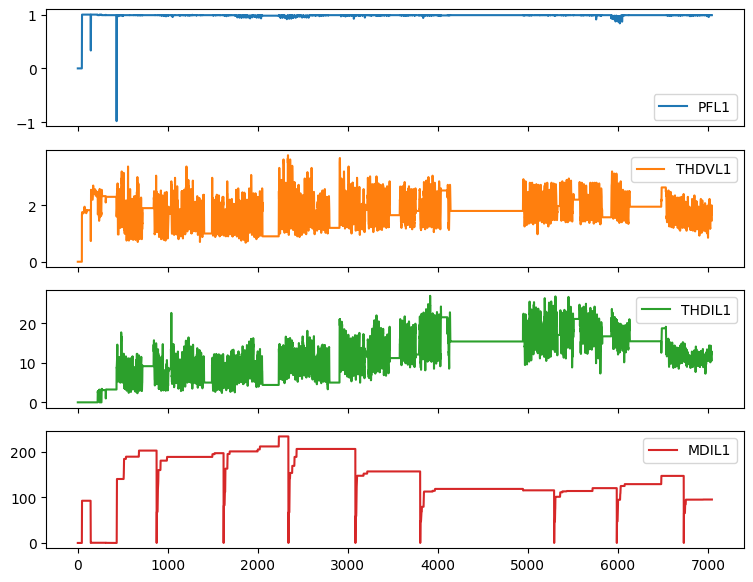

,count,mean,std,min,25%,50%,75%,max
PFL1,7045.0,0.980158,0.084485,-0.98,0.990,0.990,0.990,1.000
THDVL1,7045.0,1.795203,0.508606,0.00,1.475,1.800,2.125,3.775
THDIL1,7045.0,11.918165,5.572763,0.00,7.950,12.275,15.450,26.950
MDIL1,7045.0,144.393299,51.733771,0.00,115.600,140.500,189.500,234.000


In [ ]:
dff = pd.read_csv('Resampled_PF.csv')
dff.plot(subplots = True, figsize = (9, 7))
plt.show()

dff.describe().T

In [ ]:
"""
values = dff.values
i = 1
plt.figure(figsize = (9, 7))
for group in range(0, 4):
    plt.subplot(4, 1, i)
    plt.plot(values[:, group])
    plt.title(dff.columns[group], y = 0.5, loc = 'right')
    i += 1
plt.show()
"""

# Data preparation for LSTM

In [ ]:
def series_to_supervised(data, n_in, n_out, dropnan = True):
    '''
    Function: Converts data series to dataframe for supervised learning
    Arguments: Dataseries, timestep for input sequence, timestep for output sequence

    '''

    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()

    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]

    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]

    agg = concat(cols, axis = 1)
    agg.columns = names

    ##drop rows with NaN values
    if dropnan:
        agg.dropna(inplace = True)
    return agg

In [ ]:
dataset = dff.drop(['Date'], axis = 1)
values = dataset.values
#values = values.astype('float64')

scaler = MinMaxScaler(feature_range = (0, 1))
scaled = scaler.fit_transform(values)

reframed = series_to_supervised(scaled, 1, 1)     #1h timestep considered
reframed.head()

,var1(t-1),var2(t-1),var3(t-1),var4(t-1),var1(t),var2(t),var3(t),var4(t)
1,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
2,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
3,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
4,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
5,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0


**Data splitting into train and test**

In [ ]:
values = reframed.values
n_train_hours = 270 * 24            #9months hourly data
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]

# split into input and output
n_hours = 1
n_features = 4
n_obs = n_hours * n_features
train_X, train_y = train[:, :n_obs], train[:, -n_features]
test_X, test_y = test[:, :n_obs], test[:, -n_features]
#print(train_X.shape, len(train_X), train_y.shape)

(6480, 1, 4) (6480,) (564, 1, 4) (564,)


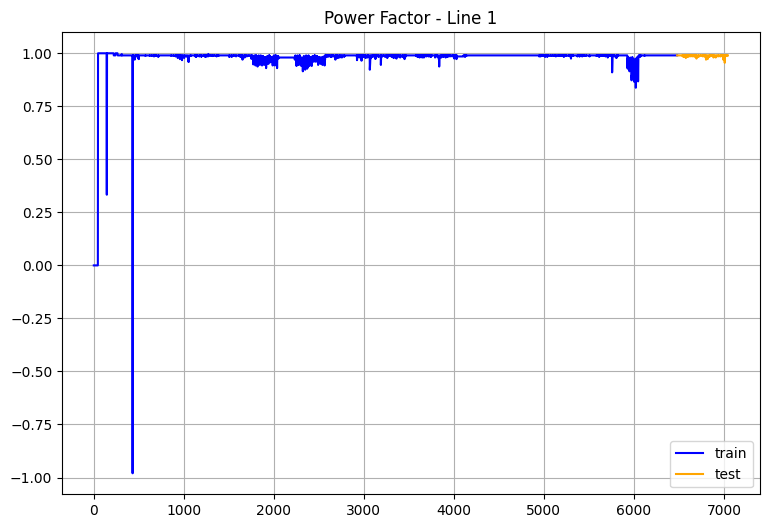

In [ ]:
# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], n_hours, n_features))
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)


plt_train = dff['PFL1'].loc[:n_train_hours]
plt_test = dff['PFL1'].loc[n_train_hours:]
plt.figure(figsize = (9, 6))
plt.plot(plt_train, label = 'train', color = 'blue')
plt.plot(plt_test, label = 'test', color = 'orange')
plt.grid()
plt.title('Power Factor - Line 1')
plt.legend()
plt.show()

> **RNNs: Backpropagation through time**

https://end-to-end-machine-learning.teachable.com/courses/how-deep-neural-networks-work/lectures/9533961

# The Model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


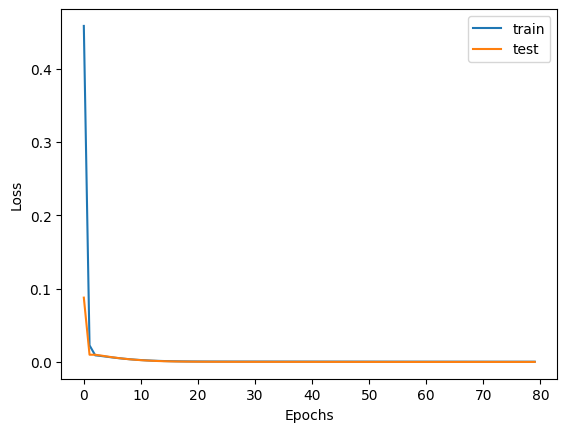

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          11,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,155 (129.52 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,104 (86.35 KB)

None
CPU times: user 24.5 s, sys: 1.29 s, total: 25.8 s
Wall time: 27 s


In [ ]:
%%time

#network with training epochs (1h timestep)
model = models.Sequential()
model.add(layers.LSTM(units = 50, input_shape = (train_X.shape[1], train_X.shape[2])))
model.add(layers.Dense(1))
#model.add(layers.Dropout(0.2))                    #try dropout to avoid overfitting
model.compile(loss = 'mse', optimizer = 'adam')    #optimization by SGD

history = model.fit(train_X, train_y, epochs = 80, batch_size = 100, validation_data = (test_X, test_y),
                    verbose = False, shuffle = False)    #verbose = 2 for displaying iterations

# plot history
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')     #validation/test loss
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

print(model.summary())

> Fitting the model: https://www.tensorflow.org/guide/keras/customizing_what_happens_in_fit
>

# Forecasts

In [ ]:
yhat = model.predict(test_X)

#invert scaling for forecasts
test_X = test_X.reshape((test_X.shape[0], test_X.shape[2]))
inv_yhat = concatenate((yhat, test_X[:,1:]), axis = 1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]

#invert scaling for actuals
test_y = test_y.reshape((len(test_y), 1))
inv_y = concatenate((test_y, test_X[:,1:]), axis = 1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:, 0]

rmse = sqrt(mean_squared_error(inv_y, inv_yhat))    #model evaluation
print('Test RMSE= %.4f' % rmse)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test RMSE= 0.0185


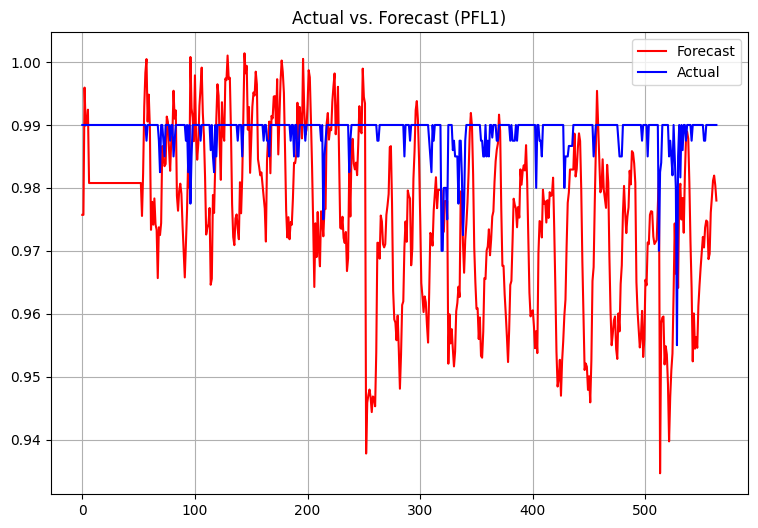

In [ ]:
plt.figure(figsize = (9, 6))
plt.plot(inv_yhat, label = 'Forecast', color = 'red')
plt.plot(inv_y, label = 'Actual', color = 'blue')
plt.title('Actual vs. Forecast (PFL1)')
plt.grid()
plt.legend()
plt.show()

> **Let us try multiple lag timesteps and hyper-parameter tuning.**

**Multiple lag timesteps LSTM**

In [ ]:
dataset = dff.drop(['Date'], axis = 1)
values = dataset.values
#values = values.astype('float64')

scaler = MinMaxScaler(feature_range = (0, 1))
scaled = scaler.fit_transform(values)
reframed = series_to_supervised(scaled, 6, 1)          #6h timestep considered
reframed.head()

,var1(t-6),var2(t-6),var3(t-6),var4(t-6),var1(t-5),var2(t-5),var3(t-5),var4(t-5),var1(t-4),var2(t-4),...,var3(t-2),var4(t-2),var1(t-1),var2(t-1),var3(t-1),var4(t-1),var1(t),var2(t),var3(t),var4(t)
6,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,...,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
7,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,...,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
8,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,...,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
9,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,...,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0
10,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,...,0.0,0.0,0.494949,0.0,0.0,0.0,0.494949,0.0,0.0,0.0


In [ ]:
values = reframed.values
n_train_hours = 270 * 24           #9months hourly data
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]

#split into input and output
n_hours = 6
n_features = 4
n_obs = n_hours * n_features
train_X, train_y = train[:, :n_obs], train[:, -n_features]
test_X, test_y = test[:, :n_obs], test[:, -n_features]
#print(train_X.shape, len(train_X), train_y.shape)

#reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], n_hours, n_features))
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(6480, 6, 4) (6480,) (559, 6, 4) (559,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


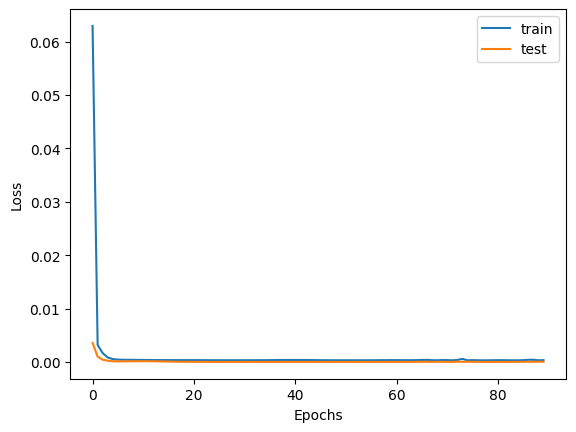

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          11,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,155 (129.52 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,104 (86.35 KB)

None
CPU times: user 51.1 s, sys: 1.56 s, total: 52.7 s
Wall time: 49.4 s


In [ ]:
%%time

model = models.Sequential()
model.add(layers.LSTM(units = 50, input_shape = (train_X.shape[1], train_X.shape[2])))
model.add(layers.Dense(1))
#model.add(layers.Dropout(0.2))
model.compile(loss = 'mse', optimizer = 'adam')

history = model.fit(train_X, train_y, epochs = 90, batch_size = 100,
                    validation_data = (test_X, test_y), verbose = False, shuffle = False)

# plot history
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

print(model.summary())

In [ ]:
yhat = model.predict(test_X)

#invert scaling for forecast
test_X = test_X.reshape((test_X.shape[0], n_hours*n_features))
inv_yhat = concatenate((yhat, test_X[:,-3:]), axis = 1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]

#invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = concatenate((test_y, test_X[:,-3:]), axis = 1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:, 0]

#Model evaluation metrics: Root Mean Squared Error
rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE= %.4f' % rmse)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Test RMSE= 0.0103


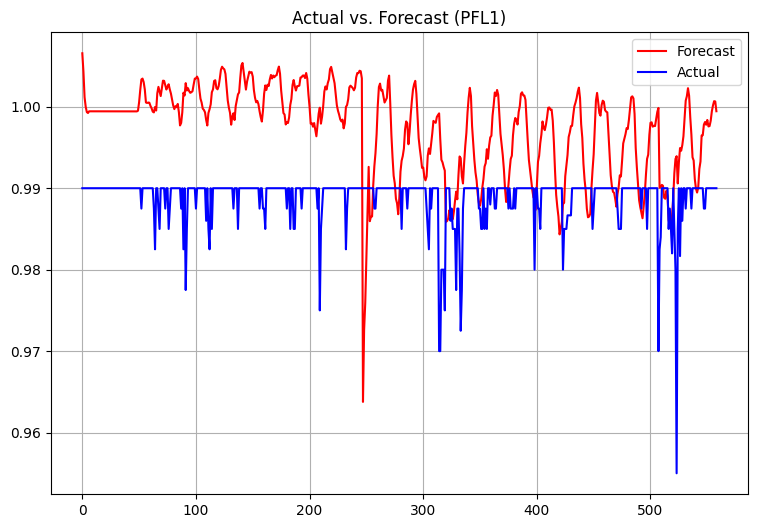

In [ ]:
plt.figure(figsize = (9, 6))
plt.plot(inv_yhat, label = 'Forecast', color = 'red')
plt.plot(inv_y, label = 'Actual', color = 'blue')
plt.title('Actual vs. Forecast (PFL1)')
plt.grid()
plt.legend()
plt.show()

> **The batch size and epoch with an 'adam' optimizer takes care of the learning rate of the algorithm.**
